## Import Dependencies

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Splitting and Hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Pipeline
from sklearn.pipeline import Pipeline

# Feature Scaling 
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures

# Joining Pipeline
from sklearn.compose import ColumnTransformer

# Imputation
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [72]:
# Configuration
pd.set_option("display.max_columns", None)

## Dataset Importing and Loading

In [73]:
df = pd.read_csv("california_housing.csv")

In [74]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Data Inspection and Understanding

In [75]:
print("\nData Shape:\n", df.shape)
print("\nData Information:")
print(df.info())
print("\nSummary Statistics:\n", df.describe())


Data Shape:
 (20640, 10)

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

Summary Statistics:
           longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861    

## Exploratory Data Analysis

In [76]:
# Check for missing values
print("\nTotal missing values: ")
print(df.isnull().sum())


Total missing values: 
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [77]:
# Check for duplicates
print("\nDuplicated records: ")
print(df.duplicated().sum())


Duplicated records: 
0


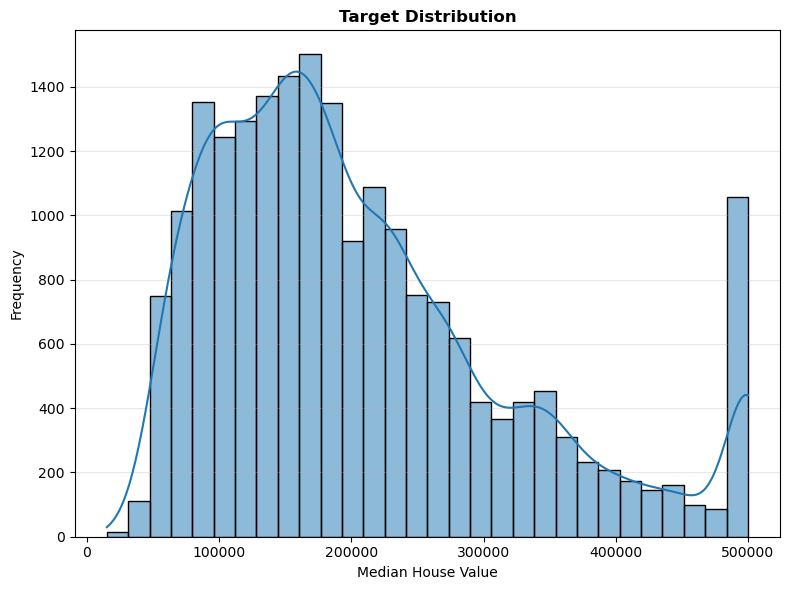

In [78]:
# Target Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df["median_house_value"], kde=True, bins=30)

plt.title("Target Distribution", fontweight="bold")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The target variable is right-skewed with a peak around 150,000–170,000, but shows an unusual spike near the 500,000 cap — suggesting values may be capped or top-coded at this threshold rather than naturally distributed.

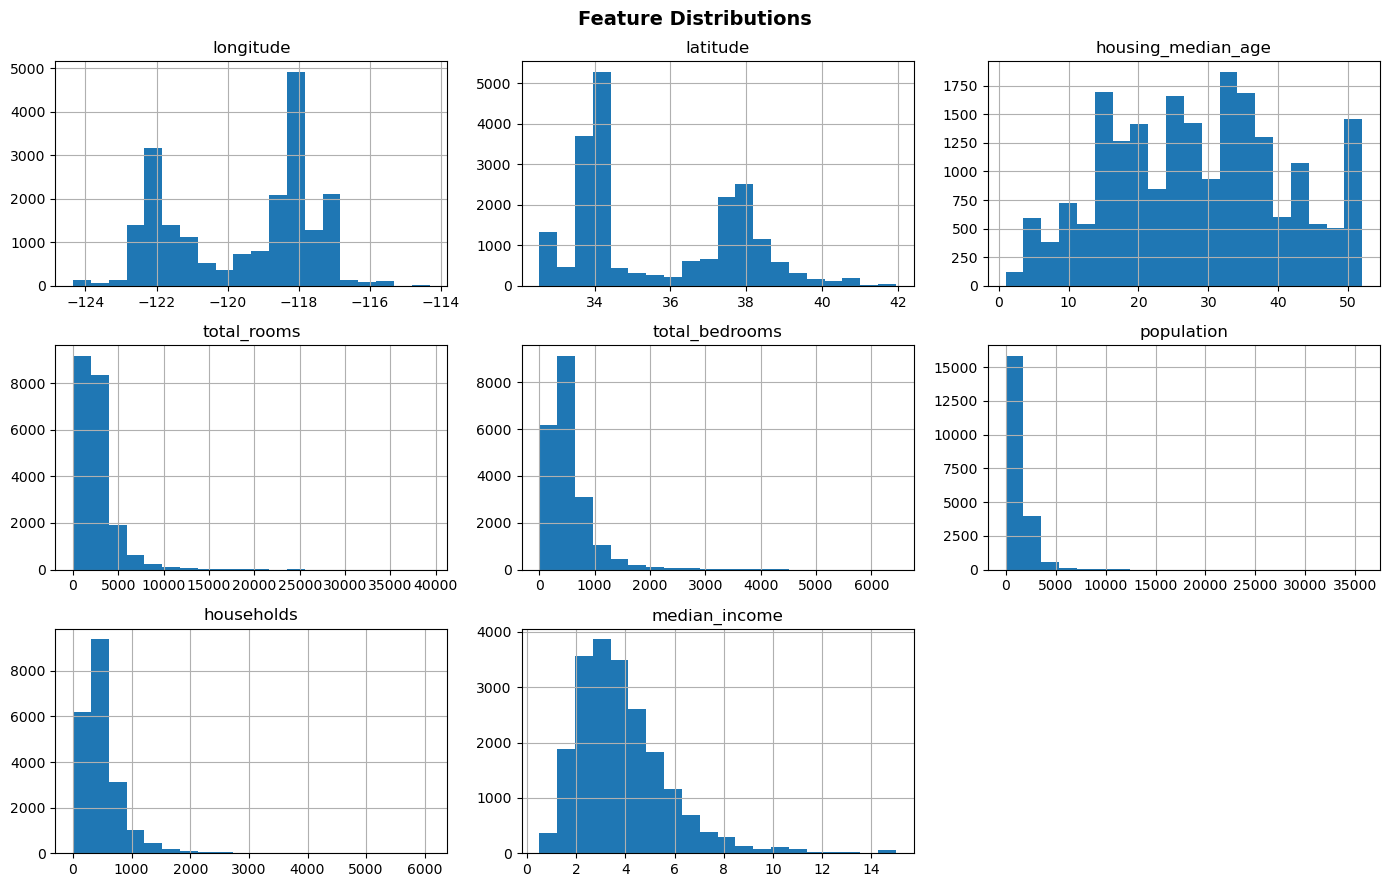

In [79]:
# Feature Distributions
df.drop("median_house_value", axis = 1).hist(figsize=(14, 9), bins=20)

plt.suptitle("Feature Distributions", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

Geographic features (longitude, latitude) show clear bimodal clusters around major metro areas (LA and SF Bay Area), while total_rooms, total_bedrooms, population, and households are heavily right-skewed with long tails — indicating a few large multi-unit or high-density blocks among mostly smaller ones.

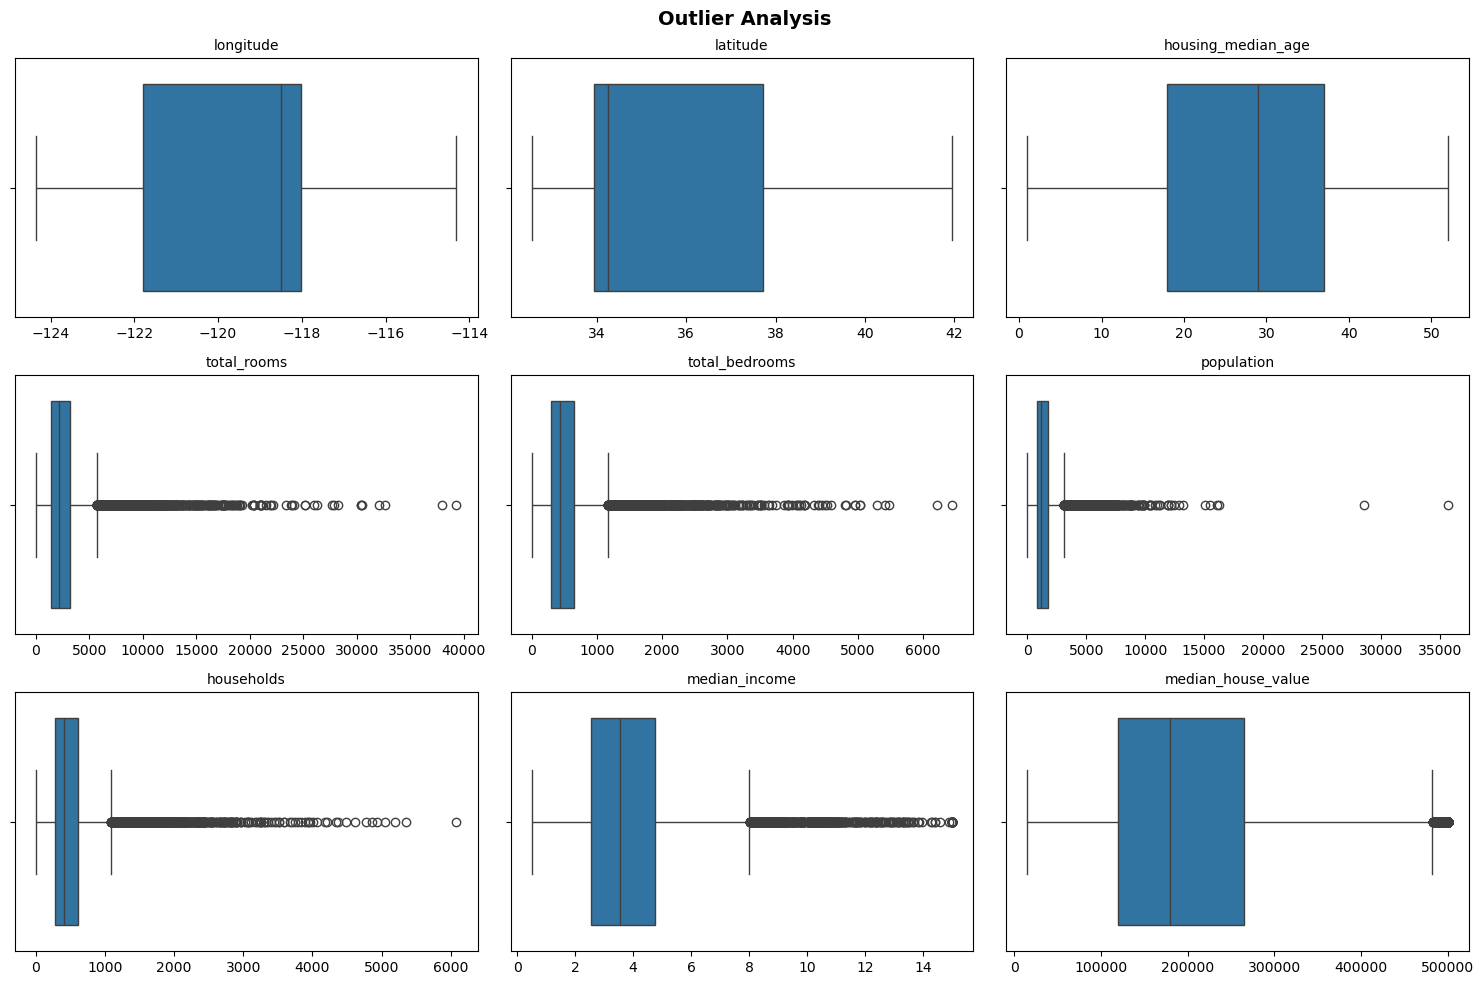

In [80]:
# Outlier Analysis
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(df.drop("ocean_proximity", axis=1)):
    sns.boxplot(data = df, x = df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.suptitle("Outlier Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Total_rooms, total_bedrooms, population and households show extensive outliers on the high end, confirming the right-skew seen in the distributions, these likely represent dense urban blocks and warrant capping, log-transforming or robust scaling would possibly handle these before modeling.

### Correlation

In [81]:
#  Feature Correlation
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


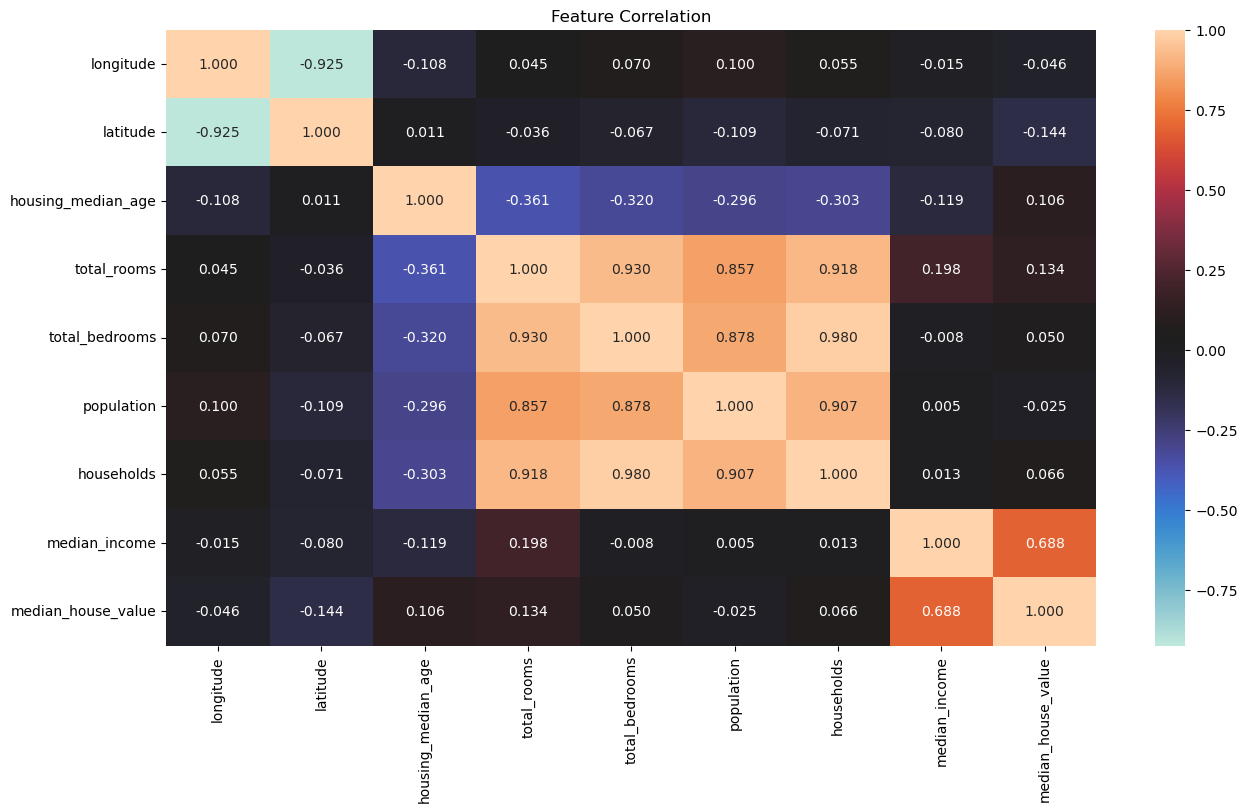

In [82]:
# Feature Correlation plot
plt.figure(figsize=(15, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="icefire")
plt.title("Feature Correlation")
plt.show()

Median_income is by far the strongest predictor of median_house_value (r = 0.688), while total_rooms, total_bedrooms, population and households show high multicollinearity with each other (r > 0.85) but little direct relationship with the target.

In [83]:
# Feature Correlation with Target
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

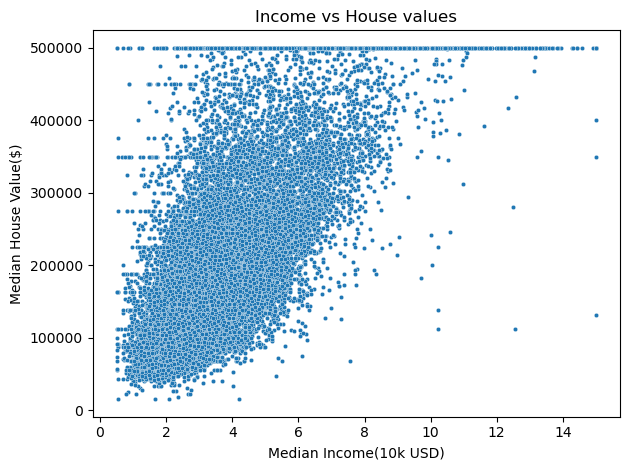

In [84]:
# Strong Feature vs Target
sns.scatterplot(data = df, x = "median_income", y = "median_house_value", s=10)
plt.title("Income vs House values")
plt.xlabel("Median Income(10k USD)")
plt.ylabel("Median House Value($)")
plt.tight_layout()
plt.show()

Median house value rises clearly with median income, confirming the 0.688 correlation seen earlier but the pronounced horizontal band at exactly 500,000 confirms the target is capped, these capped points cut across nearly all income levels and distort the true relationship.

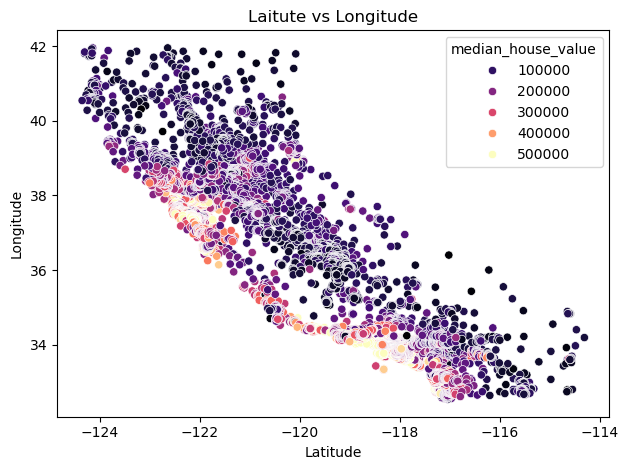

In [85]:
# Location plot
colors = sns.color_palette("viridis", len(df))
sns.scatterplot(data = df, x = "longitude", y = "latitude", hue="median_house_value", palette="magma")
plt.title("Laitute vs Longitude")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.tight_layout()
plt.show()

The highest-valued homes (yellow/orange) cluster tightly around latitude ~34 (Los Angeles) and ~37-38 (San Francisco Bay Area), both coastal regions, while inland areas consistently show lower values, confirming coastal proximity as a strong price driver.

## Data Cleaning / Preprocessing

In [86]:
# Dropping the capped rows from the target
df["median_house_value"].value_counts().sort_values(ascending = False).head()

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
Name: count, dtype: int64

In [87]:
df = df[df["median_house_value"] < 500000].reset_index(drop=True)
print(f"The remaining rows after dropping the capped target: {len(df)}")

The remaining rows after dropping the capped target: 19648


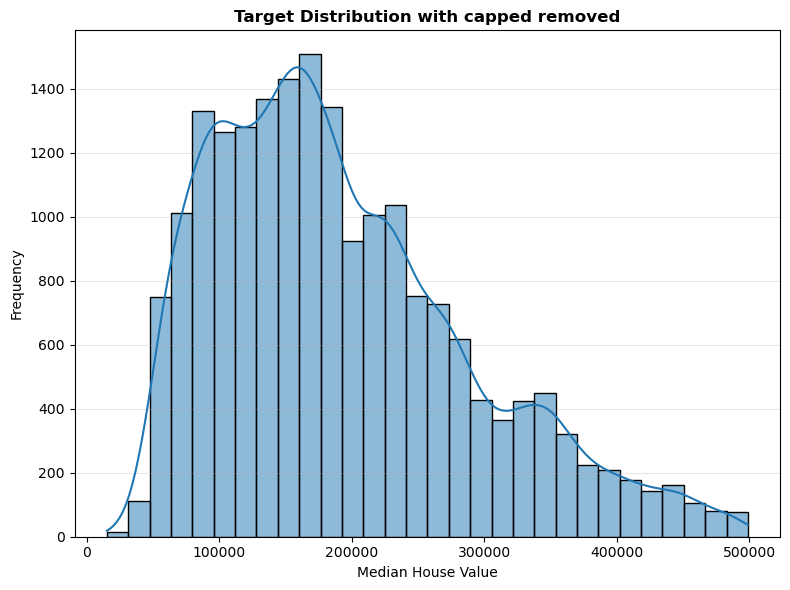

In [88]:
# Target distribution after dropping the capped target
plt.figure(figsize=(8, 6))
sns.histplot(df["median_house_value"], kde=True, bins=30)

plt.title("Target Distribution with capped removed", fontweight="bold")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
        
plt.tight_layout()
plt.show()

With the capped values at 500,000 removed, the target distribution now shows a clean, natural right-skew with a smooth tail, the artificial spike is gone, confirming those capped rows were indeed a data artifact rather than genuine high-value properties.

In [89]:
# Log Transformation
cols_to_transform = ["total_rooms", "total_bedrooms", "population", "households"]

for col in cols_to_transform:
    df[col] = np.log1p(df[col])

In [90]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,342200.0,NEAR BAY


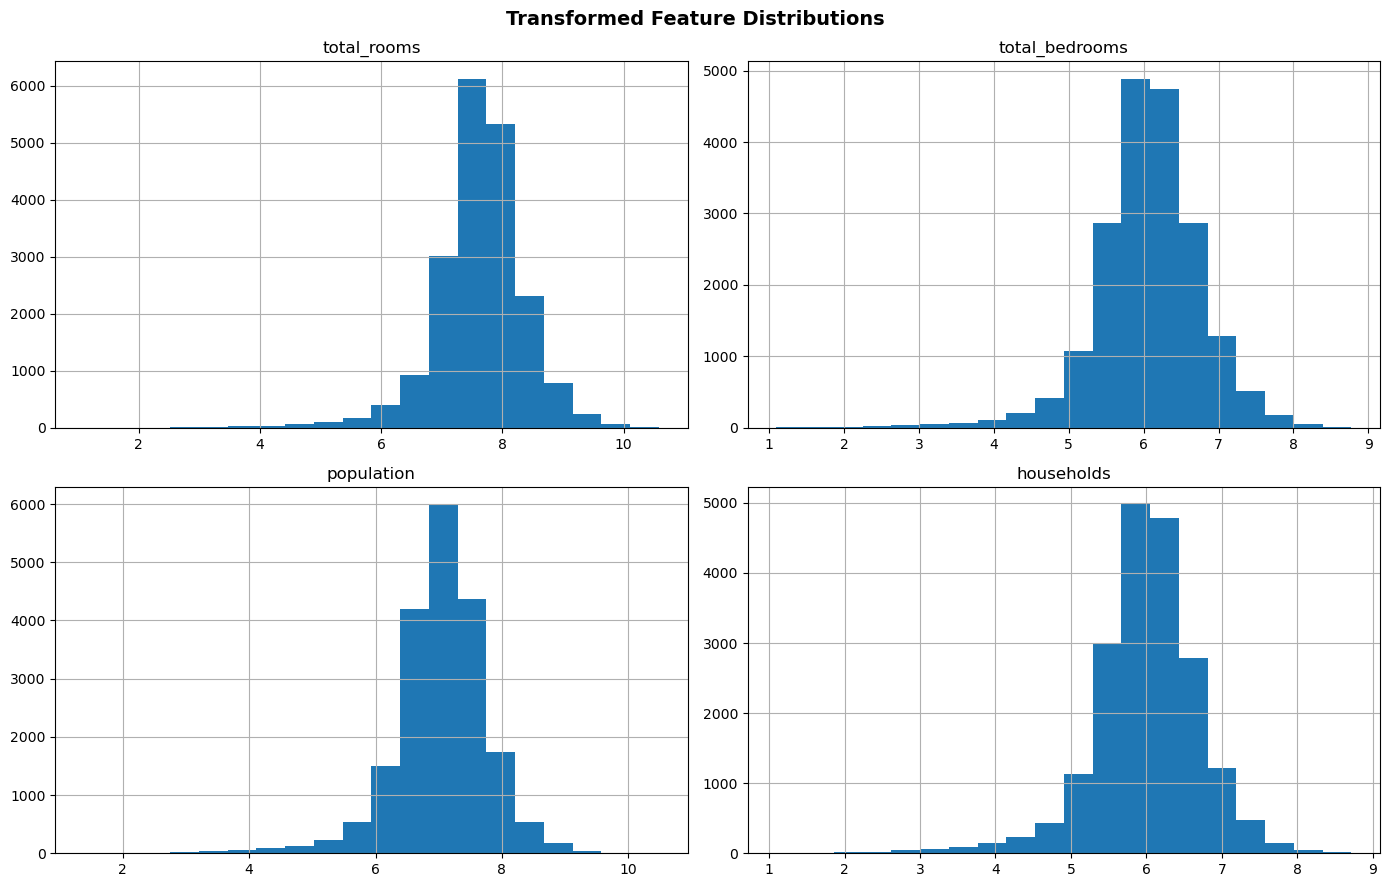

In [91]:
# Feature Distributions after log transformation
df[["total_rooms", "total_bedrooms", "population", "households"]].hist(figsize=(14, 9), bins=20)

plt.suptitle("Transformed Feature Distributions", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

These transformed features are now far better suited for linear and distance-based models, as the previous long tails and extreme outliers have been compressed into a manageable range without losing relative ordering of the data.

## Preprocessing Pipeline

In [92]:
# Separating numerical from categorical variable
numerical_cols = df.select_dtypes(include = [np.number]).columns.to_list()
numerical_cols.remove("median_house_value")
categorical_cols = df.select_dtypes(exclude = [np.number]).columns.to_list()

print(numerical_cols)
print(categorical_cols)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
['ocean_proximity']


In [93]:
# Numerical pipeline
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical pipeline
categorical_pipeline = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown = "ignore"))
    ]
)

# preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)

## Model Development and Training

In [94]:
# Create Features and Target
X = df.drop("median_house_value", axis = 1)
y = df["median_house_value"]

In [95]:
# Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (15718, 9)
Testing Data Shape: (3930, 9)


### Baseline Model

In [96]:
models = {
     "Linear Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]),

    "Lasso Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha = 1.0, max_iter=5000))
    ]),

    "Polynomial Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("poly", PolynomialFeatures(
            degree=2,
            include_bias=False
        )),
        ("model", Ridge())
    ]),

    "Support Vector Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", SVR())
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ])
}

In [97]:
# Training
results = []
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Prediction
    y_pred =  model.predict(X_test)

    # Evaluation
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # store results
    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    trained_models[name] = model

# convert the results to dataframe
results_df = pd.DataFrame(results)

# sort the results by R2
results_df = results_df.sort_values(by="R2", ascending=False)
print("\n========== INITIAL MODEL COMPARISON ==========")

print(results_df)


========== INITIAL MODEL COMPARISON ==========
                       Model           MSE          RMSE           MAE  \
5              Random Forest  2.044322e+09  45214.177317  30162.849781   
6          Gradient Boosting  2.565508e+09  50650.840333  36165.216545   
3      Polynomial Regression  2.864866e+09  53524.442185  38542.628567   
0          Linear Regression  3.543207e+09  59524.847220  43999.902125   
2           Lasso Regression  3.543241e+09  59525.130299  44000.387542   
1           Ridge Regression  3.543323e+09  59525.819544  44002.396371   
4  Support Vector Regression  9.850616e+09  99250.268657  76610.004334   

         R2  
5  0.786767  
6  0.732405  
3  0.701180  
0  0.630426  
2  0.630423  
1  0.630414  
4 -0.027468  


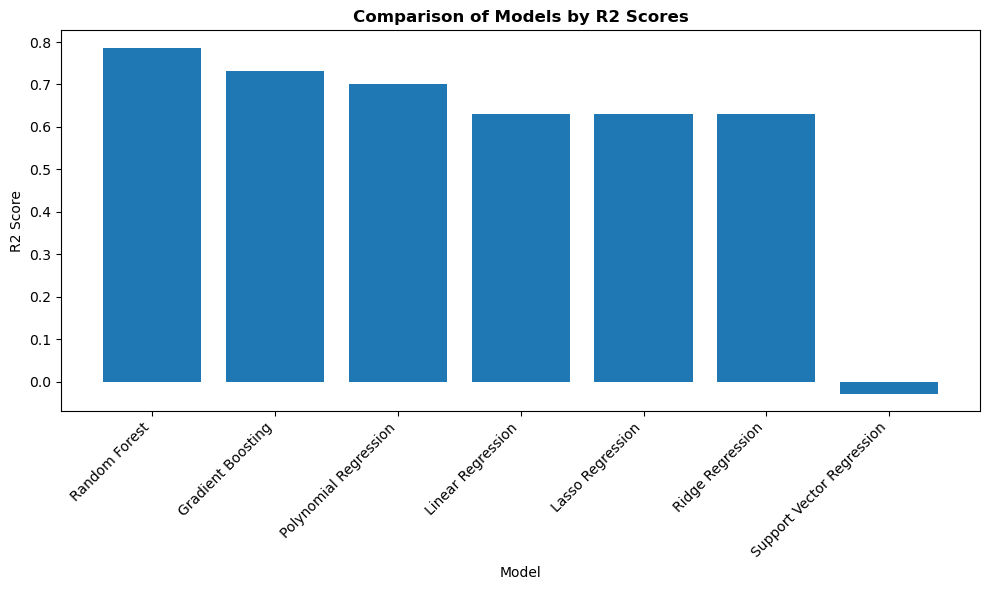

In [98]:
# Visualizing the Comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Comparison of Models by R2 Scores", fontweight="bold")

plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Random Forest clearly outperforms all other models (R² = 0.787, RMSE ≈ 45,214), followed by Gradient Boosting, both tree-based ensembles capture the non-linear relationships in the data far better than linear approaches.

## Hyperparameter Tuning

In [101]:
# Random Forest Hyperparamater Tuning
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42))
])

rf_params = {
    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        None,
        5,
        10
    ],

    "model__min_samples_split": [
        2,
        5
    ]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)


Best Random Forest Parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [103]:
# Gradient Boosting Hyperparameter Tuning
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

gb_params = {
    "model__n_estimators": [
        50,
        100,
        200
    ],

    "model__learning_rate": [
        0.01,
        0.05,
        0.1
    ],

    "model__max_depth": [
        2,
        3,
        5
    ]
}

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

gb_grid.fit(
    X_train,
    y_train
)

print("\nBest Gradient Boosting Parameters:")
print(gb_grid.best_params_)


Best Gradient Boosting Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}


In [104]:
# Ridge Hyperparameter Tuning
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(
    X_train,
    y_train
)

print("\nBest Ridge Parameters:")
print(ridge_grid.best_params_)


Best Ridge Parameters:
{'model__alpha': 0.01}


In [105]:
# Evaluating the Tuned Models
tuned_models = {

    "Tuned Ridge":
        ridge_grid.best_estimator_,

    "Tuned Random Forest":
        rf_grid.best_estimator_,

    "Tuned Gradient Boosting":
        gb_grid.best_estimator_
}


tuned_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )

    tuned_results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })


tuned_results_df = pd.DataFrame(
    tuned_results
)

print("\n========== TUNED MODEL RESULTS ==========")

print(tuned_results_df)


========== TUNED MODEL RESULTS ==========
                     Model           MAE           MSE          RMSE        R2
0              Tuned Ridge  43999.930333  3.543209e+09  59524.857434  0.630426
1      Tuned Random Forest  30022.824211  2.029636e+09  45051.486694  0.788299
2  Tuned Gradient Boosting  30097.069264  1.943592e+09  44086.191528  0.797274


Tuned Gradient Boosting now offers the best MAE (~30,097) and RMSE (~44,086) trade-off, making it the top candidate for deployment, though its lead over Tuned Random Forest is modest, so model choice could also weigh interpretability, training time and stability.

In [108]:
# Combine All the model results
all_results = pd.concat(
    [
        results_df,
        tuned_results_df
    ],
    ignore_index=True
)

all_results = all_results.sort_values(
    by="R2",
    ascending=False
)

print("\n========== FINAL MODEL COMPARISON ==========")

print(all_results)


========== FINAL MODEL COMPARISON ==========
                       Model           MSE          RMSE           MAE  \
9    Tuned Gradient Boosting  1.943592e+09  44086.191528  30097.069264   
8        Tuned Random Forest  2.029636e+09  45051.486694  30022.824211   
0              Random Forest  2.044322e+09  45214.177317  30162.849781   
1          Gradient Boosting  2.565508e+09  50650.840333  36165.216545   
2      Polynomial Regression  2.864866e+09  53524.442185  38542.628567   
3          Linear Regression  3.543207e+09  59524.847220  43999.902125   
7                Tuned Ridge  3.543209e+09  59524.857434  43999.930333   
4           Lasso Regression  3.543241e+09  59525.130299  44000.387542   
5           Ridge Regression  3.543323e+09  59525.819544  44002.396371   
6  Support Vector Regression  9.850616e+09  99250.268657  76610.004334   

         R2  
9  0.797274  
8  0.788299  
0  0.786767  
1  0.732405  
2  0.701180  
3  0.630426  
7  0.630426  
4  0.630423  
5  0.630414  

In [109]:
# Select the best model
best_model_name = all_results.iloc[0]["Model"]

print("\nBest model based on R²:")
print(best_model_name)


# Select actual model object
if best_model_name == "Tuned Ridge":

    final_model = ridge_grid.best_estimator_

elif best_model_name == "Tuned Random Forest":

    final_model = rf_grid.best_estimator_

elif best_model_name == "Tuned Gradient Boosting":

    final_model = gb_grid.best_estimator_

else:

    final_model = trained_models[
        best_model_name
    ]


Best model based on R²:
Tuned Gradient Boosting


In [110]:
# Final Model Evaluation
final_predictions = final_model.predict(X_test)

final_mae = mean_absolute_error(
    y_test, 
    final_predictions
)

final_mse = mean_squared_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    final_mse
)

final_r2 = r2_score(
    y_test,
    final_predictions
)


print("\n========== FINAL MODEL PERFORMANCE ==========")

print(
    "MAE:",
    final_mae
)

print(
    "MSE:",
    final_mse
)

print(
    "RMSE:",
    final_rmse
)

print(
    "R²:",
    final_r2
)


========== FINAL MODEL PERFORMANCE ==========
MAE: 30097.069264223483
MSE: 1943592283.4273553
RMSE: 44086.19152781691
R²: 0.7972737856085197


In [111]:
# Actual vs Predicted Values
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": final_predictions

})

print("\nActual vs Predicted:")
print(comparison.head(20))


Actual vs Predicted:
      Actual      Predicted
0   329800.0  359756.034362
1   294700.0  277605.717327
2   195700.0  193328.905006
3   161500.0  209733.822713
4   275000.0  384485.709636
5   137000.0  182982.551954
6   266000.0  302992.039996
7    81300.0   51343.345186
8    92800.0  142505.431941
9   273700.0  296253.987046
10  237000.0  216019.743820
11  271300.0  257221.038729
12  198900.0  217398.307803
13   76600.0  152214.265588
14   64900.0   62494.688996
15  201000.0  207261.261265
16   45600.0   50267.446942
17  312700.0  263578.278407
18  381400.0  272373.572972
19  208300.0  254456.575917


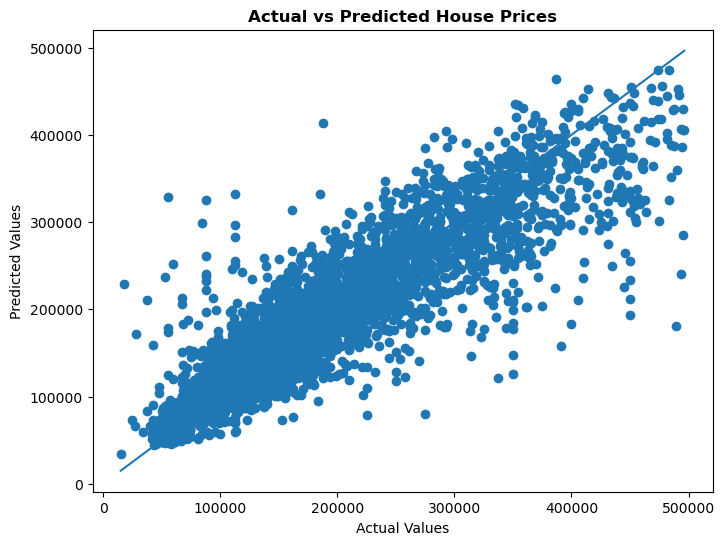

In [126]:
# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions
)

# Perfect prediction line
min_value = min(
    y_test.min(),
    final_predictions.min()
)

max_value = max(
    y_test.max(),
    final_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.title(
    "Actual vs Predicted House Prices",
    fontweight="bold"
)

plt.xlabel(
    "Actual Values"
)

plt.ylabel(
    "Predicted Values"
)

plt.show()


Predictions align closely with actual values along the diagonal for the bulk of the mid-range prices (~$100k–$350k), confirming the model's strong overall R² of 0.797 but spread widens noticeably at both the low and high ends.

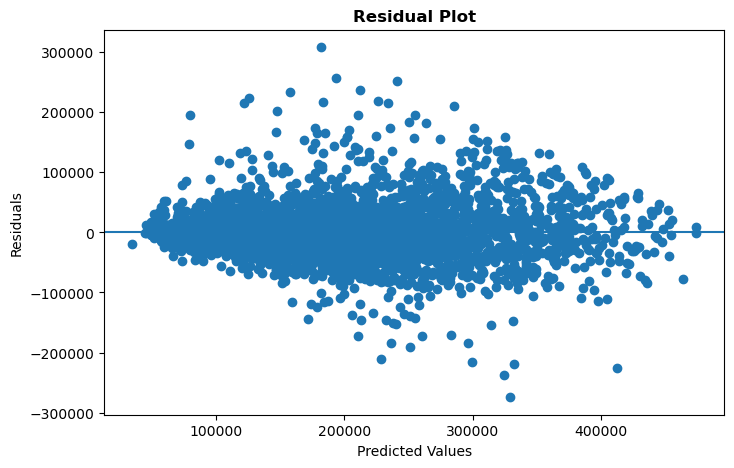

In [114]:
# Residual Analysis
residuals = (
    y_test - final_predictions
)

plt.figure(figsize=(8, 5))

plt.scatter(
    final_predictions,
    residuals
)

plt.axhline(
    y=0
)

plt.title(
    "Residual Plot",
    fontweight="bold"
)

plt.xlabel(
    "Predicted Values"
)

plt.ylabel(
    "Residuals"
)

plt.show()


Residuals are roughly centered around zero for low-to-mid predicted values, but the funnel-shaped spread widening beyond ~$200,000 indicates heteroscedasticity, the model's error grows larger and less consistent as predicted price increases.

In [129]:
# Model Interpretation
"""
For tree-based models, we can inspect feature importance.
For linear models, coefficients can be interpreted.

Because the final model may be different depending on the
results, we check which type of model was selected.
"""
if best_model_name == "Tuned Random Forest":

    importances = (
        final_model
        .named_steps["model"]
        .feature_importances_
    )

    feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
    
    feature_importance = pd.DataFrame({

        "Feature": feature_names,

        "Importance": importances

    }).sort_values(
        by="Importance",
        ascending=False
    )

    print("\nFeature Importance:")
    print(feature_importance)


elif best_model_name == "Tuned Gradient Boosting":

    importances = (
        final_model
        .named_steps["model"]
        .feature_importances_
    )

    feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
    
    feature_importance = pd.DataFrame({

        "Feature": feature_names,

        "Importance": importances

    }).sort_values(
        by="Importance",
        ascending=False
    )

    print("\nFeature Importance:")
    print(feature_importance)


elif best_model_name in [
    "Tuned Ridge",
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression"
]:

    coefficients = (
        final_model
        .named_steps["model"]
        .coef_
    )

    coefficient_df = pd.DataFrame({

        "Feature": X.columns,

        "Coefficient": coefficients

    })

    coefficient_df[
        "Absolute_Coefficient"
    ] = abs(
        coefficient_df["Coefficient"]
    )

    coefficient_df = coefficient_df.sort_values(
        by="Absolute_Coefficient",
        ascending=False
    )

    print("\nModel Coefficients:")
    print(coefficient_df)


Feature Importance:
                            Feature  Importance
7                num__median_income    0.472502
9       cat__ocean_proximity_INLAND    0.177674
0                    num__longitude    0.107381
1                     num__latitude    0.097912
2           num__housing_median_age    0.038329
5                   num__population    0.033392
4               num__total_bedrooms    0.020577
3                  num__total_rooms    0.019789
6                   num__households    0.018215
12  cat__ocean_proximity_NEAR OCEAN    0.007389
11    cat__ocean_proximity_NEAR BAY    0.003705
8    cat__ocean_proximity_<1H OCEAN    0.002494
10      cat__ocean_proximity_ISLAND    0.000640


Median_income dominates as the single most important predictor (47.3%), nearly 3x the next-highest feature, confirming the strong correlation (0.688) observed earlier and validating income as the primary economic driver of house value.

In [122]:
# Prediction on New Data

# Select one row from the test set as an example
new_data = X_test.iloc[
    [0]
]

prediction = final_model.predict(
    new_data
)

print("\n========== NEW DATA PREDICTION ==========")

print("Test features:")

print(new_data)

print(
    "\nHouse Price Prediction:",
    prediction[0]
)


========== NEW DATA PREDICTION ==========
Test features:
      longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
8541    -118.42      34.0                45.0     7.499977        5.874931   

      population  households  median_income ocean_proximity  
8541    6.784457    5.918894         5.0357       <1H OCEAN  

House Price Prediction: 359756.03436245146


In [124]:
# Save the model
import joblib

joblib.dump(
    final_model,
    "house_price_model.pkl"
)

print(
    "\nFinal model saved as: house_price_model.pkl"
)


Final model saved as: house_price_model.pkl


In [125]:
# Load the saved model

loaded_model = joblib.load(
    "house_price_model.pkl"
)

# Test loaded model
loaded_prediction = loaded_model.predict(
    new_data
)

print(
    "\nPrediction from loaded model:",
    loaded_prediction[0]
)


Prediction from loaded model: 359756.03436245146
